In this transformer model, the test and validation subsets are removed, and the model is trained on the entire trajectory. 

In the cell below the protein folding data (csdih), rmsd, and true committor trajectory (q_traj) are loaded in to the notebook.

In [1]:
import numpy as np
from scipy.io import FortranFile

# Load RMSD (optional, already done in your earlier code)
with open('../2f4kpnas380.CArmsd') as f:
    rmsd = np.array([float(l.split()[1]) for l in f], dtype=np.float32)

# Function to read your dihedral data
def read_dih(name):
    f = FortranFile(name, 'r')
    rec = f.read_record(np.dtype('i4'))
    nsets, ndih = rec[0], rec[1]
    csdih = np.zeros((nsets, ndih), dtype='f4')
    csdih = f.read_record(np.dtype('f4')).reshape((ndih, nsets)).T
    f.close()
    return csdih

# Load dihedral angles
csdih = read_dih('../csdih')

# Load committor targets
q_traj = np.load('q_traj.npy')

# Check shapes
print('csdih shape:', csdih.shape)
print('q_traj shape:', q_traj.shape)


csdih shape: (1509392, 136)
q_traj shape: (1509392,)


The cell below checks that the transformer will use GPU.

In [2]:
import torch
print(torch.cuda.is_available())  # should print True if GPU is ready


True


Need to import Sergei's optimalrcs library in order to run the validation plots after the transformer produces a trajectory.

In [3]:
import sys
sys.path.append('/home/staff7/fbsskr/Notebooks/optimalrcs-cupy/')
import optimalrcs,metrics,plots

The following cell is the transformer model, in this model the validation and test subsets are removed, meaning the model is trained on the entire trajectory and is not tested on any unseen data. 

Loading data...
Starting Overfitting Test on cuda...
Epoch 01 | Loss: 0.00107526 | LR: 1.00e-04 | Time: 33.4s
Epoch 02 | Loss: 0.00027458 | LR: 1.00e-04 | Time: 34.8s
Epoch 03 | Loss: 0.00019627 | LR: 1.00e-04 | Time: 45.2s
Epoch 04 | Loss: 0.00015653 | LR: 1.00e-04 | Time: 48.8s
Epoch 05 | Loss: 0.00013134 | LR: 1.00e-04 | Time: 40.3s
Epoch 06 | Loss: 0.00011407 | LR: 1.00e-04 | Time: 37.3s
Epoch 07 | Loss: 0.00010075 | LR: 1.00e-04 | Time: 36.6s
Epoch 08 | Loss: 0.00009218 | LR: 1.00e-04 | Time: 35.4s
Epoch 09 | Loss: 0.00008280 | LR: 1.00e-04 | Time: 36.1s
Epoch 10 | Loss: 0.00007631 | LR: 1.00e-04 | Time: 33.5s
Epoch 11 | Loss: 0.00007152 | LR: 1.00e-04 | Time: 39.5s
Epoch 12 | Loss: 0.00006747 | LR: 1.00e-04 | Time: 33.7s
Epoch 13 | Loss: 0.00006288 | LR: 1.00e-04 | Time: 35.7s
Epoch 14 | Loss: 0.00005887 | LR: 1.00e-04 | Time: 44.2s
Epoch 15 | Loss: 0.00005640 | LR: 1.00e-04 | Time: 35.5s
Epoch 16 | Loss: 0.00005345 | LR: 1.00e-04 | Time: 32.9s
Epoch 17 | Loss: 0.00005137 | LR: 1

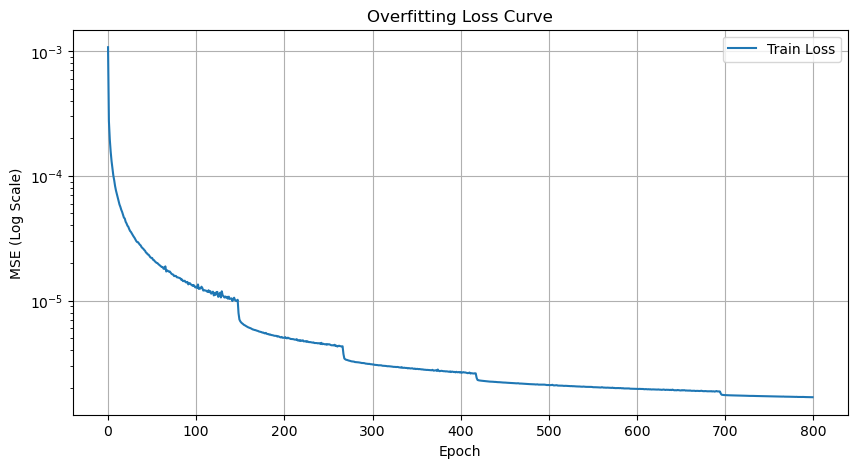

Generating full predictions (seed_r)...
Final Pearson r: 0.999994


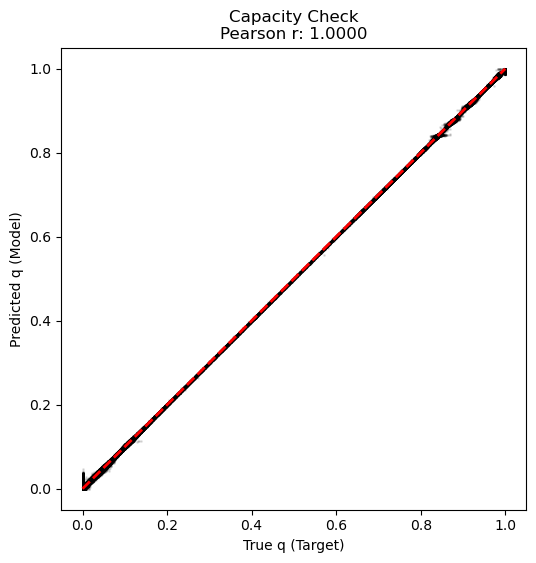

In [4]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import time

# ------------------------
# 1) Dataset
# ------------------------
class ProteinDataset(Dataset):
    def __init__(self, features, targets, window=6):
        self.features = features
        self.targets = targets
        self.window = window
        self.length = len(features) - window 

    def __len__(self):
        return max(0, self.length)

    def __getitem__(self, idx):
        # Sliding window: returns shape (window, 136)
        x = self.features[idx: idx + self.window]
        # Target: committor at the END of the window
        y = self.targets[idx + self.window - 1]
        return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)

# ------------------------
# 2) Transformer Model
# ------------------------
class TransformerCommittor(nn.Module):
    def __init__(self, input_dim=136, d_model=128, nhead=4, num_layers=3, dim_feedforward=512, 
                 dropout=0.1, max_seq_len=50): 
        super().__init__()
        self.proj_in = nn.Linear(input_dim, d_model)
        # Learned positional embeddings
        self.pos_emb = nn.Embedding(max_seq_len + 1, d_model)
        # CLS token
        self.cls_token = nn.Parameter(torch.randn(1, 1, d_model))

        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead,
                                                   dim_feedforward=dim_feedforward,
                                                   dropout=dropout, activation='relu',
                                                   batch_first=True)
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        self.head = nn.Sequential(
            nn.Linear(d_model, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )
        self._init_weights()

    def _init_weights(self):
        nn.init.xavier_uniform_(self.proj_in.weight)
        nn.init.normal_(self.pos_emb.weight, std=0.02)
        nn.init.normal_(self.cls_token, std=0.02)

    def forward(self, x):
        B, T, D = x.shape
        x = self.proj_in(x)
        pos_ids = torch.arange(T, device=x.device).unsqueeze(0).expand(B, T)
        x = x + self.pos_emb(pos_ids)
        
        cls_tokens = self.cls_token.expand(B, -1, -1)
        x = torch.cat([cls_tokens, x], dim=1)
        
        encoded = self.encoder(x)
        cls_emb = encoded[:, 0, :]
        return self.head(cls_emb).squeeze(1)

# ------------------------
# 3) Training Function (FIXED: removed verbose)
# ------------------------
def train_overfit(model, train_loader, n_epochs=800, lr=1e-4, device='cuda'):
    model.to(device)
    model.train()
    
    criterion = nn.MSELoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-6)
    
    # FIXED: Removed 'verbose=True' to prevent TypeError
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', patience=5, factor=0.5
    )
    
    losses = []

    print(f"Starting Overfitting Test on {device}...")
    for epoch in range(1, n_epochs + 1):
        t0 = time.time()
        running_loss = 0.0
        n_samples = 0
        
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            
            optimizer.zero_grad()
            preds = model(xb)
            loss = criterion(preds, yb)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item() * xb.size(0)
            n_samples += xb.size(0)

        epoch_loss = running_loss / n_samples
        losses.append(epoch_loss)
        
        # Step scheduler
        scheduler.step(epoch_loss)

        # Manually print LR if needed since verbose is off
        current_lr = optimizer.param_groups[0]['lr']
        print(f"Epoch {epoch:02d} | Loss: {epoch_loss:.8f} | LR: {current_lr:.2e} | Time: {time.time()-t0:.1f}s")

    return losses

# ------------------------
# 4) Main Execution
# ------------------------
def main():
    # --- A) SETUP ---
    csdih_path = 'csdih.npy'
    q_path = 'q_traj.npy'
    
    window = 6           
    batch_size = 256
    n_epochs = 800       
    device = 'cuda' if torch.cuda.is_available() else 'cpu'

    # --- B) LOAD & NORMALIZE ---
    print("Loading data...")
    csdih = np.load(csdih_path, mmap_mode='r')
    q_traj = np.load(q_path, mmap_mode='r')
    
    mean = np.mean(csdih, axis=0)
    std = np.std(csdih, axis=0) + 1e-8
    # Keep as float32 for PyTorch efficiency
    csdih_norm = ((csdih - mean) / std).astype(np.float32)

    # --- C) DATASET ---
    # Using the whole dataset for training (Capacity Check)
    full_ds = ProteinDataset(csdih_norm, q_traj, window=window)
    train_loader = DataLoader(full_ds, batch_size=batch_size, shuffle=True, num_workers=0, pin_memory=True)

    # --- D) MODEL & TRAIN ---
    model = TransformerCommittor(input_dim=136, max_seq_len=window, dropout=0.0) 
    losses = train_overfit(model, train_loader, n_epochs=n_epochs, lr=1e-4, device=device)

    # --- E) PLOT LOSS ---
    plt.figure(figsize=(10,5))
    plt.plot(losses, label='Train Loss')
    plt.yscale('log')
    plt.title('Overfitting Loss Curve')
    plt.xlabel('Epoch')
    plt.ylabel('MSE (Log Scale)')
    plt.legend()
    plt.grid(True)
    
    # ### ADDED: Save Loss Plot ###
    plt.savefig('Capacity_Check_Loss.png', dpi=300, bbox_inches='tight')
    plt.show()

    # --- F) GENERATE SEED_R (PREDICTIONS) ---
    print("Generating full predictions (seed_r)...")
    eval_loader = DataLoader(full_ds, batch_size=1024, shuffle=False, num_workers=0, pin_memory=True)
    
    model.eval()
    preds_list = []
    targets_list = []
    
    with torch.no_grad():
        for xb, yb in eval_loader:
            xb = xb.to(device)
            p = model(xb)
            preds_list.append(p.cpu().numpy())
            targets_list.append(yb.numpy())
    global seed_r
    seed_r = np.concatenate(preds_list)
    targets = np.concatenate(targets_list)
    
    corr, _ = pearsonr(seed_r, targets)
    print(f"Final Pearson r: {corr:.6f}")

    # Visual check
    plt.figure(figsize=(6,6))
    plt.scatter(targets, seed_r, s=1, alpha=0.1, c='k')
    plt.plot([0,1], [0,1], 'r--', lw=2)
    plt.xlabel('True q (Target)')
    plt.ylabel('Predicted q (Model)')
    plt.title(f'Capacity Check\nPearson r: {corr:.4f}')
    
    # ### ADDED: Save Scatter Plot ###
    plt.savefig('Capacity_Check_Scatter.png', dpi=300, bbox_inches='tight')
    plt.show()

main()

These results show that the training loss coverges to zero over sufficient epochs, showing that given time, the model can reproduce the committor point for point. This is confirmed by the perfect linear relationship with pearson correlation value 1.00.

The code below defines i_traj (step) and t_traj (time), in order to call the validtion plots (q2).

In [5]:
i_traj=np.ones_like(rmsd)
t_traj=np.asarray(range(len(rmsd)))
print (i_traj[:10])
print (t_traj[:10])

[1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
[0 1 2 3 4 5 6 7 8 9]


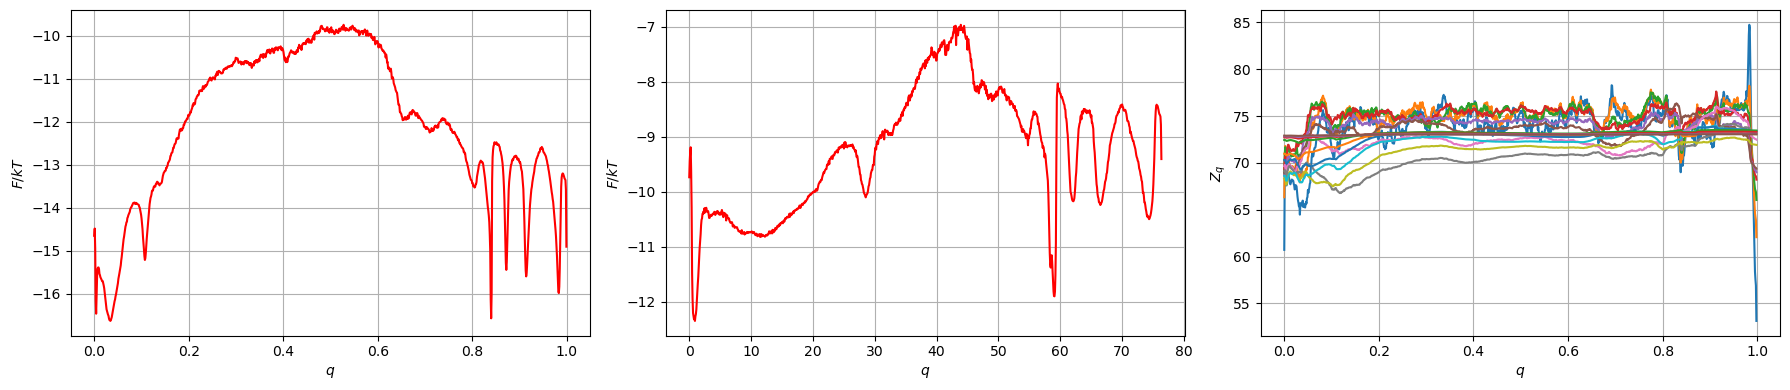

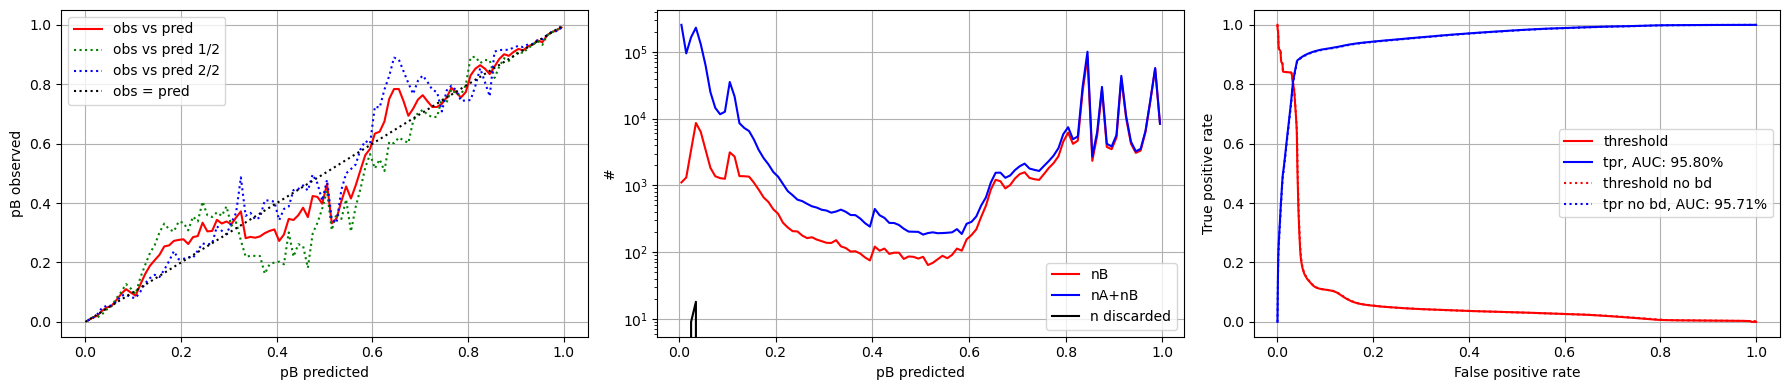

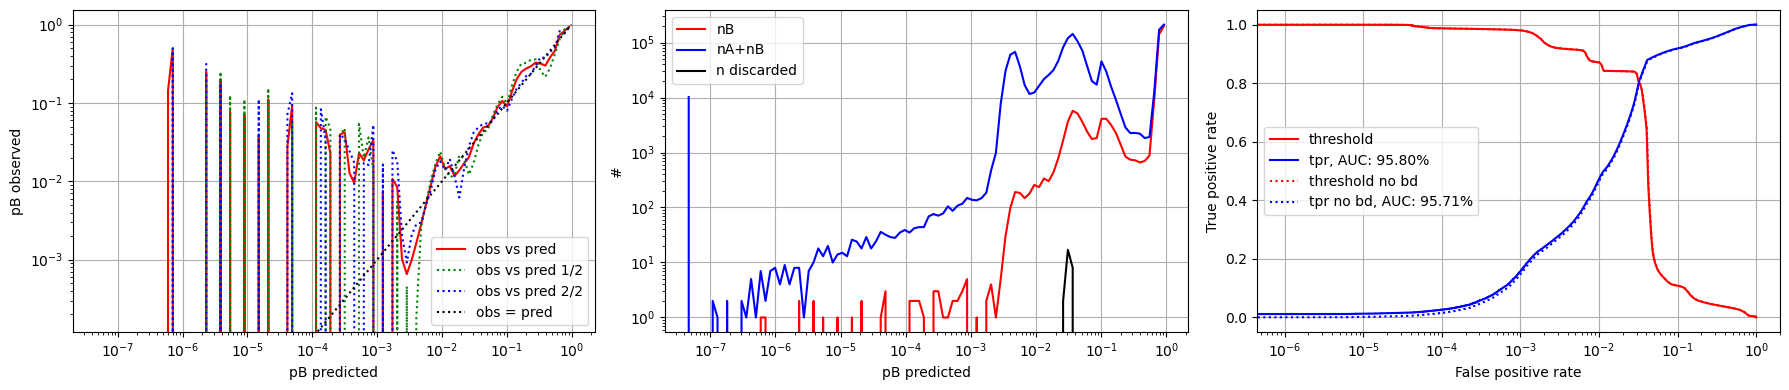

In [6]:
import matplotlib.pyplot as plt
from unittest.mock import patch

# --- 1. Define your q2 object (Ensure slicing matches seed_r length!) ---
# Note: Double check that len(rmsd[7:]) is exactly equal to len(seed_r)
# If using a window of 6 centered, you likely need rmsd[3:-3] as discussed.
q2 = optimalrcs.CommittorNE(
    boundary0=rmsd[6:] > 10.5,
    boundary1=rmsd[6:] < 1.0,
    i_traj=i_traj[6:],
    t_traj=t_traj[6:],
    seed_r=seed_r
)

# --- 2. Save Free Energy Profiles (FEPs) ---
with patch('matplotlib.pyplot.show'):
    q2.plots_feps()          # Generate plot (plt.show is blocked)
    fig = plt.gcf()          # Get Current Figure
    fig.savefig('FEP_Profiles_MAX.png', dpi=300, bbox_inches='tight') # Save High Quality
    plt.show()               # Show in notebook manually

# --- 3. Save Predicted vs Observed ---
with patch('matplotlib.pyplot.show'):
    q2.plots_obs_pred()
    fig = plt.gcf()
    fig.savefig('Pred_vs_Obs_MAX.png', dpi=300, bbox_inches='tight')
    plt.show()

# --- 4. Save Predicted vs Observed (Log Scale) ---
with patch('matplotlib.pyplot.show'):
    q2.plots_obs_pred(log_scale=True)
    fig = plt.gcf()
    fig.savefig('Pred_vs_Obs_Log_MAX.png', dpi=300, bbox_inches='tight')
    plt.show()

This valiation criterion (Zq) plot performs to the same level as that of the optimised committor, showing invariance across all lag times across the trajectory. The cells below overlay the FEPs with Sergeis. 


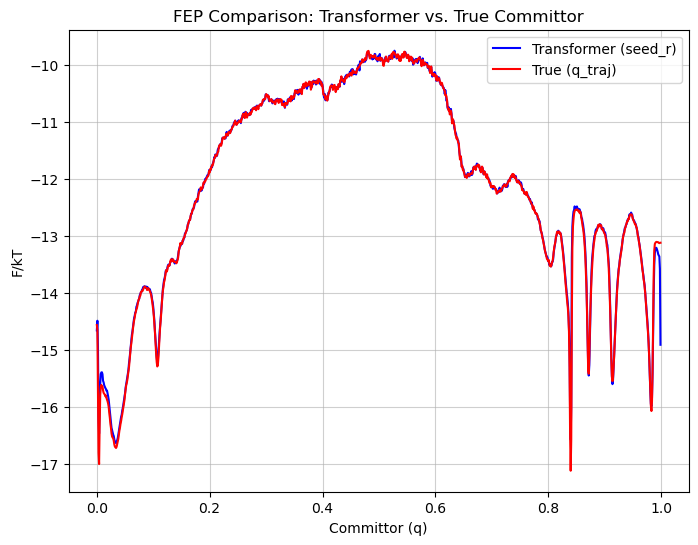

In [7]:
import matplotlib.pyplot as plt
from optimalrcs import plots

# 1. Slice the TRUE committor to match the Transformer's output length
# (Assuming window=6 as per your code)
q_traj_true = q_traj[6:] 

# 2. Create a single figure
fig, ax = plt.subplots(figsize=(8, 6))

# 3. Plot YOUR Prediction (seed_r)
# We plot this first (Blue)
plots.plot_fep(ax, q2.r_traj, i_traj=q2.i_traj, t_traj=q2.t_traj)

# 4. Plot the TRUE Reference (q_traj) on the SAME axis
# We plot this second (Red)
plots.plot_fep(ax, q_traj_true, i_traj=q2.i_traj, t_traj=q2.t_traj)

# 5. Customize the lines for clarity
lines = ax.get_lines()
if len(lines) >= 2:
    # Set the Transformer/LSTM prediction to Blue
    lines[0].set_color('blue')
    lines[0].set_label('Transformer (seed_r)') 
    
    # Set the True Committor to Red
    lines[-1].set_color('red')
    lines[-1].set_label('True (q_traj)')
    
    ax.legend()

# 6. Add Grid and Labels
ax.grid(True, which='both', linestyle='-', alpha=0.6)
ax.set_ylabel('F/kT')
ax.set_xlabel('Committor (q)')
plt.title("FEP Comparison: Transformer vs. True Committor")

# --- SAVE COMMAND GOES HERE ---
# dpi=300: High resolution (good for papers)
# bbox_inches='tight': Prevents axis labels from being cut off
fig.savefig('FEP_T_Comparison_Overlay_MAX.png', dpi=300, bbox_inches='tight')

# 7. Show the plot
plt.show()

Overlayed committor FEP shows near perfect agreement

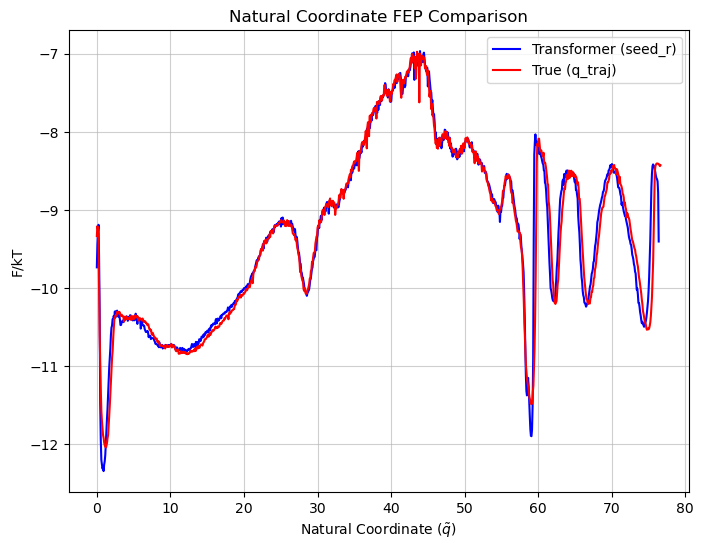

In [8]:
import matplotlib.pyplot as plt
import cupy as cp  # Import CuPy to handle GPU arrays
from optimalrcs import plots

# 1. Slice the TRUE committor (CPU side)
# (Assuming window=6 as per your previous context)
q_traj_cpu = q_traj[6:]

# 2. Convert to GPU Array for the library
# This fixes the "NotImplementedError"
q_traj_true = cp.asarray(q_traj_cpu)

# 3. Create a single figure
fig, ax = plt.subplots(figsize=(8, 6))

# 4. Plot YOUR Transformer Prediction (Natural Coordinate)
# q2.r_traj is likely already on GPU inside the q2 object
plots.plot_fep(ax, q2.r_traj, i_traj=q2.i_traj, t_traj=q2.t_traj, natural=True)

# 5. Plot the TRUE Reference (Natural Coordinate)
# Now passing the GPU array 'q_traj_true'
plots.plot_fep(ax, q_traj_true, i_traj=q2.i_traj, t_traj=q2.t_traj, natural=True)

# 6. Customize the lines
lines = ax.get_lines()
if len(lines) >= 2:
    lines[0].set_color('blue')
    lines[0].set_label('Transformer (seed_r)')  # Updated label to match your model type
    lines[-1].set_color('red')
    lines[-1].set_label('True (q_traj)')
    ax.legend()

# 7. Final Polish
ax.grid(True, which='both', linestyle='-', alpha=0.6)
ax.set_ylabel('F/kT')
ax.set_xlabel('Natural Coordinate ($\\tilde{q}$)')
plt.title("Natural Coordinate FEP Comparison")

# --- SAVE COMMAND ---
# Saves the figure as a high-quality PNG (300 DPI)
fig.savefig('Natural_Coordinate_FEP_T_Comparison_MAX.png', dpi=300, bbox_inches='tight')

# 8. Show the plot
plt.show()

Near perfect agreement also seen for natural coordinate

In [ ]:
The cells below calcualte the discrepancy metrics used to calculate how closely FEPs match. 

In [9]:
import numpy as np
from scipy.stats import entropy

# Helper function to ensure arrays are on CPU
def ensure_numpy(arr):
    if hasattr(arr, 'get'):
        return arr.get()
    if hasattr(arr, 'cpu'):
        return arr.detach().cpu().numpy()
    return np.asarray(arr)

def calculate_discrepancy(q_pred, q_true, bins=100, hist_range=None):
    # 1. Force inputs to be Standard NumPy Arrays (CPU)
    q_pred = ensure_numpy(q_pred)
    q_true = ensure_numpy(q_true)

    # 2. Determine Range Automatically if not provided
    # This is crucial for Natural Coordinates which are not bound to [0,1]
    if hist_range is None:
        min_val = min(np.min(q_pred), np.min(q_true))
        max_val = max(np.max(q_pred), np.max(q_true))
        hist_range = (min_val, max_val)

    # 3. Compute Histograms
    p_pred, _ = np.histogram(q_pred, bins=bins, range=hist_range, density=True)
    p_true, _ = np.histogram(q_true, bins=bins, range=hist_range, density=True)
    
    # 4. Avoid log(0) errors
    epsilon = 1e-10
    p_pred = np.maximum(p_pred, epsilon)
    p_true = np.maximum(p_true, epsilon)
    
    # 5. Calculate Free Energies (F = -ln P)
    f_pred = -np.log(p_pred)
    f_true = -np.log(p_true)
    
    # Shift minima to 0
    f_pred -= np.min(f_pred)
    f_true -= np.min(f_true)
    
    # --- METRIC 1: RMSE ---
    mask = (p_true > epsilon) & (p_pred > epsilon)
    rmse = np.sqrt(np.mean((f_pred[mask] - f_true[mask])**2))
    
    # --- METRIC 2: KL Divergence ---
    kl_div = entropy(p_true, p_pred)
    
    return rmse, kl_div

In [10]:
import cupy as cp
from optimalrcs import plots

# --- Part A: Standard Committor Metrics ---
# (Using the q_traj_true you sliced in the previous step, e.g. q_traj[start:end])
rmse_q, kl_q = calculate_discrepancy(q2.r_traj, q_traj_true, hist_range=(0,1))

print(f"--- Standard Committor (q) ---")
print(f"RMSE: {rmse_q:.4f} kT")
print(f"KL Div: {kl_q:.4f}")


# --- Part B: Natural Coordinate Metrics ---

# 1. Prepare GPU arrays (Library requires GPU for transformation)
# We assume q2.r_traj is already on GPU (it usually is inside the object)
# We convert the ground truth to GPU
q_true_gpu = cp.asarray(q_traj_true)
q_pred_gpu = cp.asarray(q2.r_traj)

# 2. Transform to Natural Coordinates
# We use the library's internal function to integrate D(q)
# This generates the data used for the second plot (ax2)
qn_pred = plots.transform_q2qn(q_pred_gpu, i_traj=q2.i_traj, t_traj=q2.t_traj)
qn_true = plots.transform_q2qn(q_true_gpu, i_traj=q2.i_traj, t_traj=q2.t_traj)

# 3. Calculate Metrics on the transformed data
rmse_nat, kl_nat = calculate_discrepancy(qn_pred, qn_true)

print(f"\n--- Natural Coordinate (q_tilde) ---")
print(f"RMSE: {rmse_nat:.4f} kT")
print(f"KL Div: {kl_nat:.4f}")

# --- Interpretation ---
print("\n--- Interpretation ---")
if rmse_q < 0.5 and rmse_nat > 1.0:
    print("Result: Good Statics, Poor Dynamics.")
    print("The model correctly ranks states (q is good) but fails to capture")
    print("the correct speed/diffusion of the folding process (q_natural is bad).")
    print("Likely cause: The model is 'smoothing' the trajectory noise.")
elif rmse_nat < 1.0:
    print("Result: Excellent Dynamics!")
    print("The model captures both the reaction pathway and the diffusion rate.")

--- Standard Committor (q) ---
RMSE: 0.0669 kT
KL Div: 0.0010

--- Natural Coordinate (q_tilde) ---
RMSE: 0.2677 kT
KL Div: 0.0210

--- Interpretation ---
Result: Excellent Dynamics!
The model captures both the reaction pathway and the diffusion rate.
